Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost loaded successfully.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Skipping XGBoost model.")

print("All libraries imported!")

XGBoost loaded successfully.
All libraries imported!


Load Dataset

In [2]:
import urllib.request
import os

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
DATA_PATH = "online_retail.xlsx"

if not os.path.exists(DATA_PATH):
    print("Downloading dataset... (this may take a minute)")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Download complete!")
else:
    print("Dataset already exists locally. Loading from disk.")

df_raw = pd.read_excel(DATA_PATH, dtype={'CustomerID': str})
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Download complete!
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


Quick Data Inspection

In [3]:
print("=== Data Types ===")
print(df_raw.dtypes)
print()
print("=== Null Values ===")
print(df_raw.isnull().sum())

=== Data Types ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

=== Null Values ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Data Cleaning
Four cleaning steps in order:

Drop rows where CustomerID is null — we can't do any customer-level analysis without it
Remove cancelled invoices (they start with 'C') — cancellations shouldn't count as purchases
Remove rows where Quantity or UnitPrice is ≤ 0 — those are data errors
Create a TotalPrice column = Quantity × UnitPrice — we'll need this for RFM

In [35]:
df = df_raw.copy()

before = len(df)
df.dropna(subset=['CustomerID'], inplace=True)
print(f"Removed {before - len(df):,} rows with missing CustomerID")

before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Removed {before - len(df):,} cancelled invoices")

before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"Removed {before - len(df):,} rows with bad Quantity/Price")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice']  = df['Quantity'] * df['UnitPrice']
df.reset_index(drop=True, inplace=True)

print(f"\nFinal cleaned shape : {df.shape}")
print(f"Date range          : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Unique customers    : {df['CustomerID'].nunique():,}")
print(f"Unique invoices     : {df['InvoiceNo'].nunique():,}")
print(f"Remaining nulls     :\n{df.isnull().sum()}")

Removed 135,080 rows with missing CustomerID
Removed 8,905 cancelled invoices
Removed 40 rows with bad Quantity/Price

Final cleaned shape : (397884, 9)
Date range          : 2010-12-01 → 2011-12-09
Unique customers    : 4,338
Unique invoices     : 18,532
Remaining nulls     :
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


Date Range & Basic Stats
Just a sanity check — confirm the date range, count unique customers and products. Always good to know the scale of your data before EDA.

In [36]:
print(f"Earliest transaction: {df['InvoiceDate'].min()}")
print(f"Latest transaction:   {df['InvoiceDate'].max()}")
print(f"Unique customers:     {df['CustomerID'].nunique()}")
print(f"Unique products:      {df['StockCode'].nunique()}")
print(f"Unique countries:     {df['Country'].nunique()}")

Earliest transaction: 2010-12-01 08:26:00
Latest transaction:   2011-12-09 12:50:00
Unique customers:     4338
Unique products:      3665
Unique countries:     37


EDA: 4-Panel Overview Plot
Four plots in one figure:

Top-left: Which countries generate the most revenue
Top-right: Monthly revenue trend (spot seasonality)
Bottom-left: Distribution of log(order value) — log scale because order values are very skewed
Bottom-right: Top 10 products by quantity sold

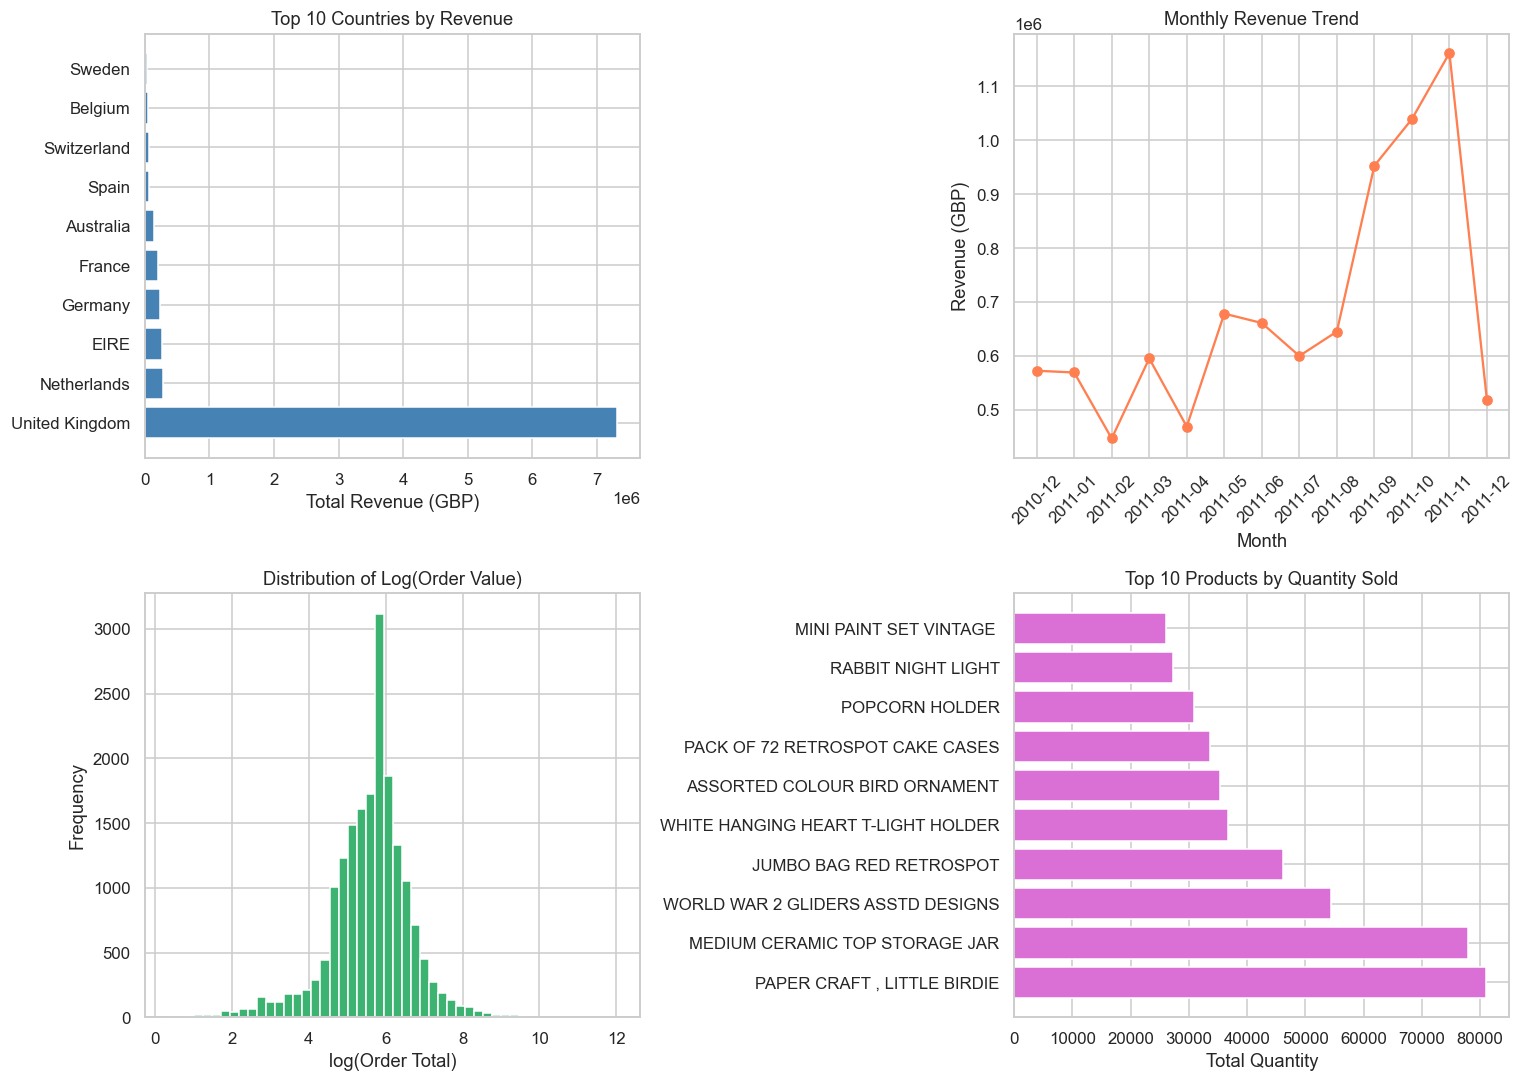

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 10 countries by revenue
country_rev = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[0, 0].barh(country_rev.index, country_rev.values, color='steelblue')
axes[0, 0].set_title('Top 10 Countries by Revenue')
axes[0, 0].set_xlabel('Total Revenue (GBP)')

# Monthly revenue trend
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_rev = df.groupby('YearMonth')['TotalPrice'].sum()
axes[0, 1].plot(monthly_rev.index.astype(str), monthly_rev.values, marker='o', color='coral')
axes[0, 1].set_title('Monthly Revenue Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Revenue (GBP)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Distribution of order values
order_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()
axes[1, 0].hist(np.log1p(order_totals), bins=50, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Distribution of Log(Order Value)')
axes[1, 0].set_xlabel('log(Order Total)')
axes[1, 0].set_ylabel('Frequency')

# Top 10 products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
axes[1, 1].barh(top_products.index, top_products.values, color='orchid')
axes[1, 1].set_title('Top 10 Products by Quantity Sold')
axes[1, 1].set_xlabel('Total Quantity')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

EDA: Orders by Day of Week
Which day of the week is busiest? We extract the day name and count unique invoices per day. This kind of plot is useful for operational insights.

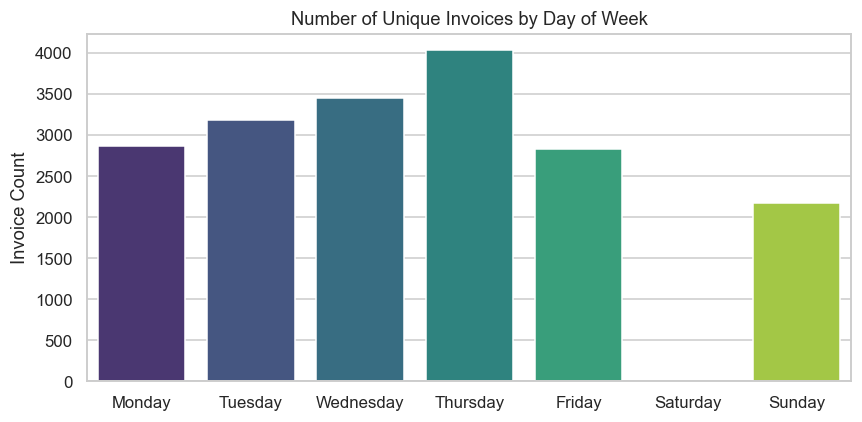

In [7]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(day_order)

plt.figure(figsize=(8, 4))
sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='viridis')
plt.title('Number of Unique Invoices by Day of Week')
plt.ylabel('Invoice Count')
plt.xlabel('')
plt.tight_layout()
plt.show()

RFM Feature Engineering
This is the core feature engineering step. We group by CustomerID and compute:

Recency: days since last purchase (relative to one day after the dataset ends)
Frequency: number of unique invoices
Monetary: total spend

In [37]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"RFM shape        : {rfm.shape}")
print(f"Reference date   : {reference_date.date()}")
print(f"\nRFM Summary:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

RFM shape        : (4338, 4)
Reference date   : 2011-12-10

RFM Summary:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


RFM Raw Distribution
Before scaling, always visualize distributions. All three RFM features are heavily right-skewed — a few big spenders and frequent buyers pull the tail. This tells us we need log-transformation before clustering.

In [38]:
rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']])

print("After log transform:")
print(pd.DataFrame(rfm_scaled, columns=['R_scaled','F_scaled','M_scaled']).describe().round(3))

After log transform:
       R_scaled  F_scaled  M_scaled
count  4338.000  4338.000  4338.000
mean     -0.000    -0.000     0.000
std       1.000     1.000     1.000
min      -2.341    -0.955    -4.005
25%      -0.661    -0.955    -0.686
50%       0.090    -0.362    -0.062
75%       0.845     0.653     0.654
max       1.564     5.859     4.732


Log-Transform + Scale RFM
Two steps here:

np.log1p: log(1 + x) — handles zeros safely and compresses the right tail
StandardScaler: brings all features to mean=0, std=1 so no single feature dominates the distance calculations in clustering



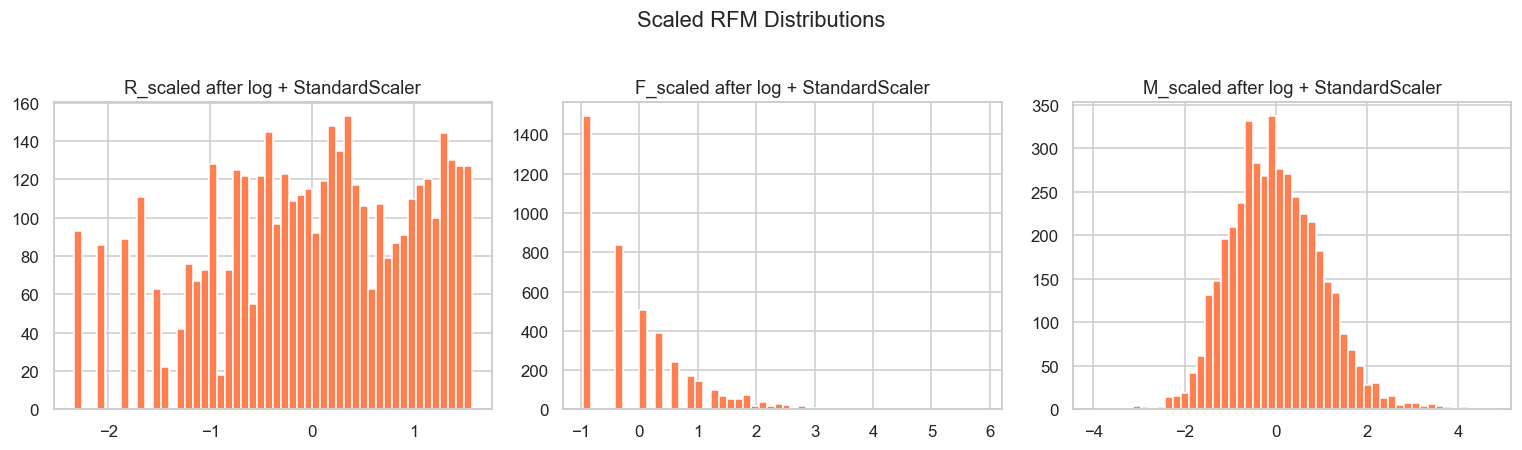

RFM features scaled and ready for clustering!


In [10]:
rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['R_scaled', 'F_scaled', 'M_scaled'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['R_scaled', 'F_scaled', 'M_scaled']):
    axes[i].hist(rfm_scaled_df[col], bins=50, color='coral', edgecolor='white')
    axes[i].set_title(f'{col} after log + StandardScaler')
plt.suptitle('Scaled RFM Distributions', y=1.02)
plt.tight_layout()
plt.show()

print("RFM features scaled and ready for clustering!")

Elbow Method (Finding Best K)
We train K-Means for k=2 to 11 and record the inertia (WCSS — within-cluster sum of squares) each time. As k increases, inertia always drops. The "elbow" is where the drop slows down sharply — that's your best k. We annotate k=4 with a red dashed line.

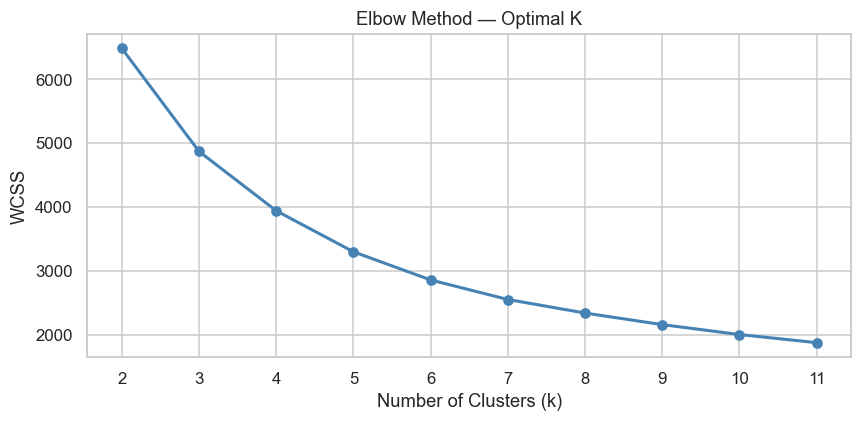

k=2  →  WCSS: 6481.23
k=3  →  WCSS: 4867.85
k=4  →  WCSS: 3938.51
k=5  →  WCSS: 3295.98
k=6  →  WCSS: 2855.01
k=7  →  WCSS: 2548.91
k=8  →  WCSS: 2336.78
k=9  →  WCSS: 2155.65
k=10  →  WCSS: 1999.90
k=11  →  WCSS: 1872.83


In [39]:
wcss = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

for k, w in zip(k_range, wcss):
    print(f"k={k}  →  WCSS: {w:.2f}")

Silhouette Score (Confirming Best K)
Silhouette score = how well-separated the clusters are. Score of 1 means perfect separation, 0 means overlapping, -1 means wrong assignment. We plot it across k values to confirm k=4 is a good choice.

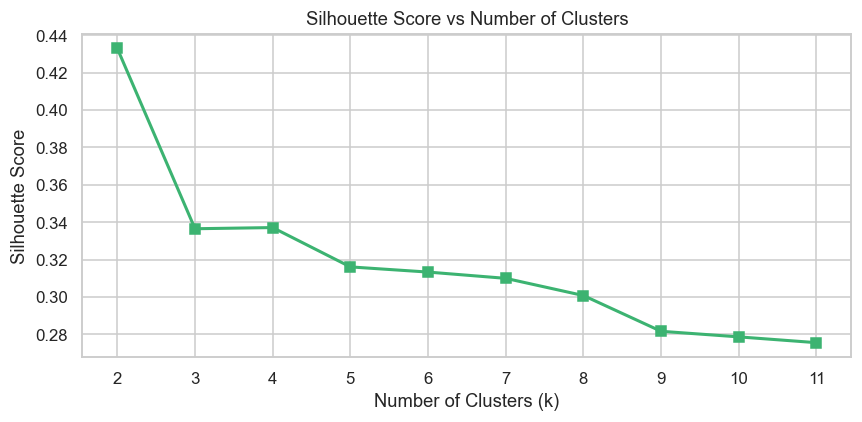

k=2  →  Silhouette: 0.4329
k=3  →  Silhouette: 0.3365
k=4  →  Silhouette: 0.3371
k=5  →  Silhouette: 0.3161
k=6  →  Silhouette: 0.3133
k=7  →  Silhouette: 0.3100
k=8  →  Silhouette: 0.3008
k=9  →  Silhouette: 0.2817
k=10  →  Silhouette: 0.2787
k=11  →  Silhouette: 0.2756


In [40]:
sil_scores = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='s', color='mediumseagreen', linewidth=2)
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}  →  Silhouette: {s:.4f}")

Fit K-Means (k=4)
Now we actually fit K-Means with k=4 and store the cluster assignments in the rfm dataframe. k-means++ initialization is used instead of random init — it spreads the initial centroids out, leading to better and more consistent results.

In [41]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"Cluster distribution:")
print(rfm['KMeans_Cluster'].value_counts().sort_index())
print(f"\nCluster centers (scaled):")
centers = pd.DataFrame(kmeans.cluster_centers_, 
                        columns=['R_scaled','F_scaled','M_scaled'])
print(centers.round(3))

Cluster distribution:
KMeans_Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64

Cluster centers (scaled):
   R_scaled  F_scaled  M_scaled
0    -0.846    -0.372    -0.401
1    -1.244     1.657     1.402
2     0.140     0.318     0.521
3     0.890    -0.777    -0.797


Hierarchical Clustering: Dendrogram
We can't plot a dendrogram for all 4000+ customers (it'd be unreadable), so we sample 300. linkage(method='ward') minimizes within-cluster variance at each merge step. The height of each horizontal line tells you how dissimilar two clusters were when they merged.

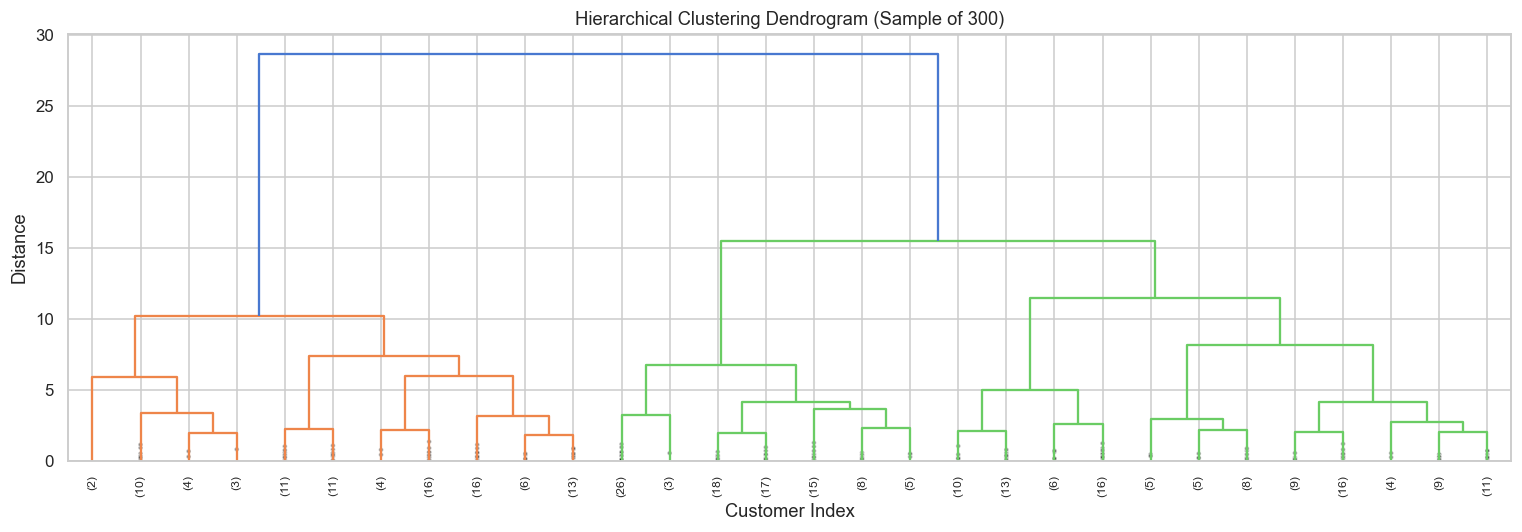

Hierarchical cluster distribution:
Hier_Cluster
0    1820
1    1364
2     242
3     912
Name: count, dtype: int64

Silhouette - K-Means     : 0.3371
Silhouette - Hierarchical: 0.2419


In [42]:
sample_idx = np.random.choice(len(rfm_scaled), size=300, replace=False, )
sample_data = rfm_scaled[sample_idx]

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    color_threshold=0.7 * max(linked[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram (Sample of 300)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

hier_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
rfm['Hier_Cluster'] = hier_model.fit_predict(rfm_scaled)

print("Hierarchical cluster distribution:")
print(rfm['Hier_Cluster'].value_counts().sort_index())

sil_hier = silhouette_score(rfm_scaled, rfm['Hier_Cluster'])
sil_km   = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
print(f"\nSilhouette - K-Means     : {sil_km:.4f}")
print(f"Silhouette - Hierarchical: {sil_hier:.4f}")

Fit Agglomerative Clustering
We fit AgglomerativeClustering on the full scaled data with n_clusters=4 to match K-Means. Ward linkage is used — same as the dendrogram.

In [15]:
hier_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
rfm['Hier_Cluster'] = hier_model.fit_predict(rfm_scaled)

print("Hierarchical cluster distribution:")
print(rfm['Hier_Cluster'].value_counts().sort_index())

Hierarchical cluster distribution:
Hier_Cluster
0    1820
1    1364
2     242
3     912
Name: count, dtype: int64


DBSCAN: K-Distance Plot (Finding eps)
DBSCAN needs two parameters: eps (neighborhood radius) and min_samples. The k-distance plot helps pick eps — we find the 5th nearest neighbor distance for each point, sort them, and look for the "knee" in the curve. That knee is a good eps.

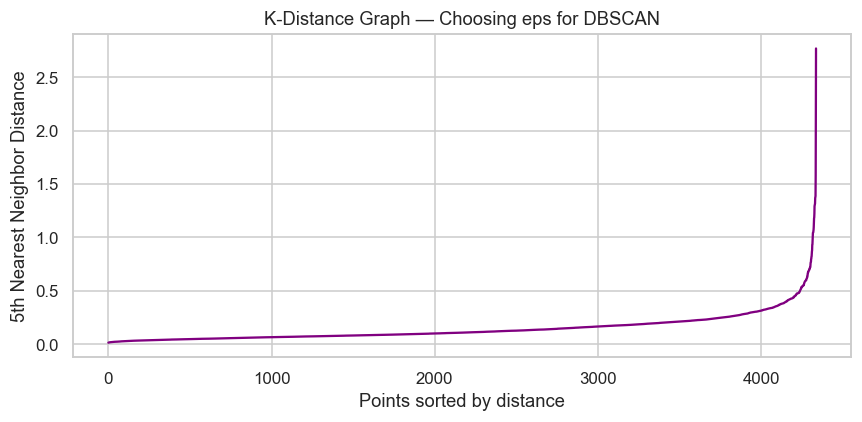

Clusters found : 2
Noise points   : 62 (1.4%)

Cluster distribution:
DBSCAN_Cluster
-1      62
 0    2791
 1    1485
Name: count, dtype: int64

Silhouette - DBSCAN (non-noise only): 0.2931


In [44]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(rfm_scaled)
distances, _ = nn.kneighbors(rfm_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph — Choosing eps for DBSCAN')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.tight_layout()
plt.show()

dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise    = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise} ({100*n_noise/len(rfm):.1f}%)")
print(f"\nCluster distribution:")
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())

sil_dbscan_mask = rfm['DBSCAN_Cluster'] != -1
sil_dbscan = silhouette_score(rfm_scaled[sil_dbscan_mask], rfm.loc[sil_dbscan_mask, 'DBSCAN_Cluster'])
print(f"\nSilhouette - DBSCAN (non-noise only): {sil_dbscan:.4f}")

Fit DBSCAN
DBSCAN labels outliers as -1. We count how many clusters were found and how many points were marked as noise. Unlike K-Means, you don't tell DBSCAN how many clusters to find — it discovers them from density.


In [17]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise    = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN found {n_clusters} clusters")
print(f"Noise points (outliers): {n_noise} ({100*n_noise/len(rfm):.1f}%)")
print()
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN found 2 clusters
Noise points (outliers): 62 (1.4%)

DBSCAN_Cluster
-1      62
 0    2791
 1    1485
Name: count, dtype: int64


Clustering Comparison Table
Side-by-side comparison of all three methods. For DBSCAN we only compute silhouette on non-noise points (noise points with label -1 aren't part of any cluster so they shouldn't be scored).

In [18]:
dbscan_mask = rfm['DBSCAN_Cluster'] != -1
sil_kmeans = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
sil_hier   = silhouette_score(rfm_scaled, rfm['Hier_Cluster'])
sil_dbscan = silhouette_score(rfm_scaled[dbscan_mask], rfm.loc[dbscan_mask, 'DBSCAN_Cluster']) if dbscan_mask.sum() > 1 else -1

results_clustering = pd.DataFrame({
    'Algorithm'       : ['K-Means', 'Hierarchical', 'DBSCAN'],
    'N Clusters'      : [rfm['KMeans_Cluster'].nunique(),
                         rfm['Hier_Cluster'].nunique(),
                         n_clusters],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Noise Points'    : [0, 0, n_noise]
})

print(results_clustering.to_string(index=False))
print()
print("✅ K-Means gives the best balance: interpretable clusters + high silhouette score.")

   Algorithm  N Clusters  Silhouette Score  Noise Points
     K-Means           4            0.3371             0
Hierarchical           4            0.2419             0
      DBSCAN           2            0.2931            62

✅ K-Means gives the best balance: interpretable clusters + high silhouette score.


PCA for Cluster Visualization
We reduce the 3 scaled RFM features to 2 principal components so we can plot the clusters. PCA finds the directions of maximum variance in the data.

Variance explained by PC1 : 75.1%
Variance explained by PC2 : 18.8%
Total variance retained   : 93.9%


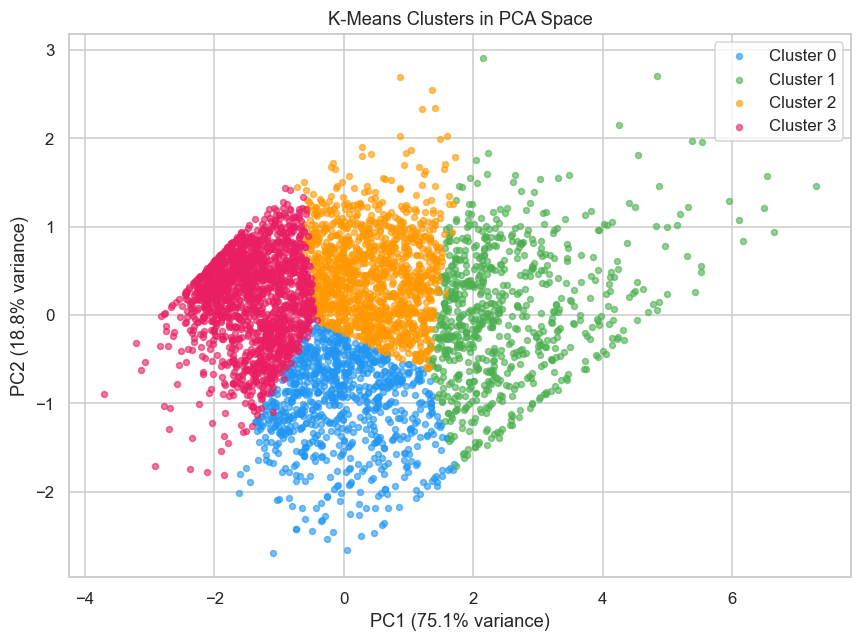

In [45]:
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(rfm_scaled)

rfm['PC1'] = rfm_2d[:, 0]
rfm['PC2'] = rfm_2d[:, 1]

print(f"Variance explained by PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance retained   : {sum(pca.explained_variance_ratio_)*100:.1f}%")

plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for i in range(OPTIMAL_K):
    mask = rfm['KMeans_Cluster'] == i
    plt.scatter(rfm.loc[mask, 'PC1'], rfm.loc[mask, 'PC2'],
                s=15, alpha=0.6, label=f'Cluster {i}', color=colors[i])

plt.title('K-Means Clusters in PCA Space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

Plot All 3 Clusterings in PCA Space
Three scatter plots side by side — one per clustering algorithm — all in the same 2D PCA space. This lets you visually compare how similar the cluster assignments are.

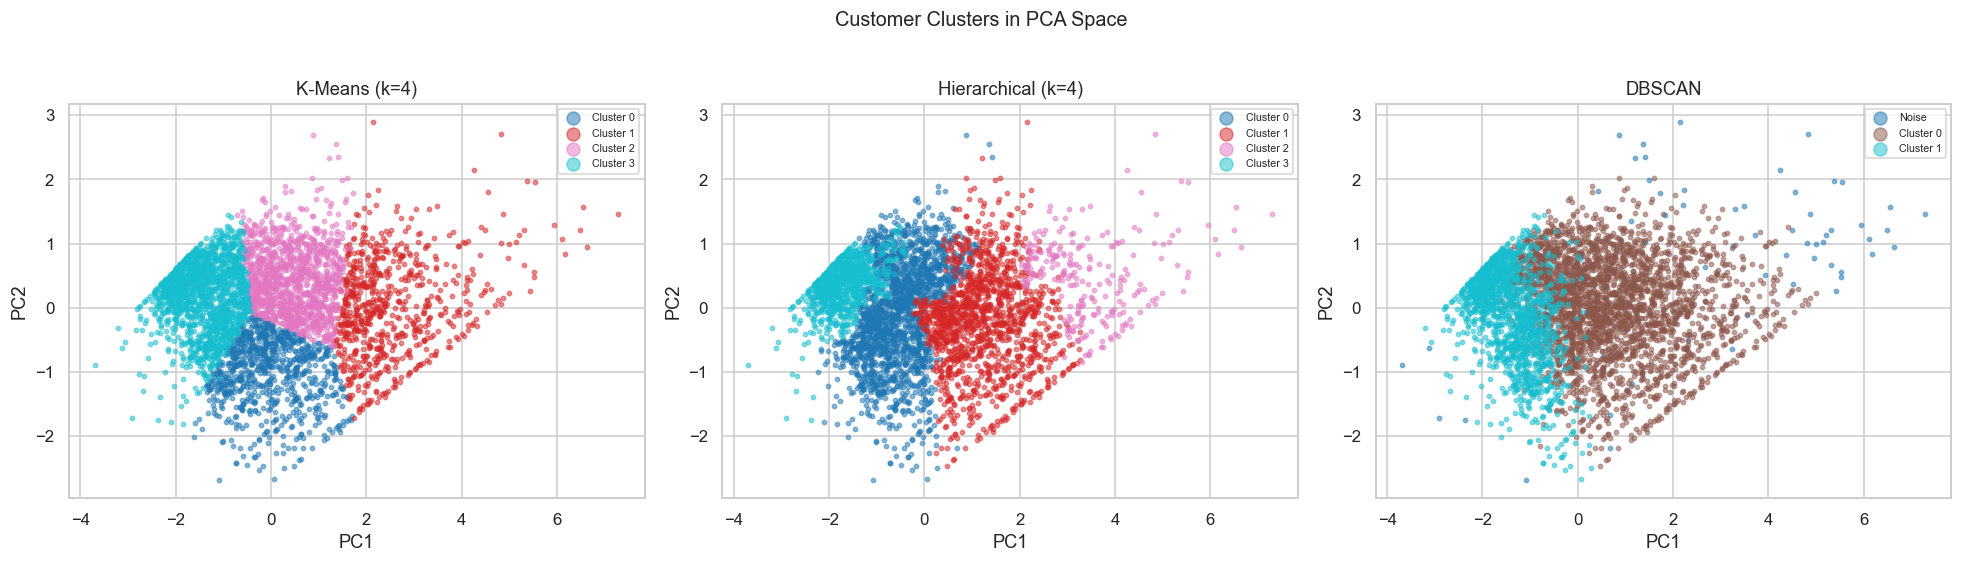

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_cols = ['KMeans_Cluster', 'Hier_Cluster', 'DBSCAN_Cluster']
titles       = ['K-Means (k=4)', 'Hierarchical (k=4)', 'DBSCAN']

for ax, col, title in zip(axes, cluster_cols, titles):
    unique_labels = sorted(rfm[col].unique())
    colors = plt.cm.get_cmap('tab10', len(unique_labels))
    for i, label in enumerate(unique_labels):
        mask = rfm[col] == label
        name = f'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(rfm.loc[mask, 'PC1'], rfm.loc[mask, 'PC2'],
                   s=8, alpha=0.5, label=name, color=colors(i))
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=3, fontsize=7)

plt.suptitle('Customer Clusters in PCA Space', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Cluster Interpretation (Mean RFM per Cluster)
We look at the mean Recency, Frequency, and Monetary for each K-Means cluster. This is how you translate cluster numbers into business language. A cluster with low Recency + high Monetary = Champions.


In [46]:
cluster_summary = rfm.groupby('KMeans_Cluster').agg(
    Count     = ('CustomerID', 'count'),
    Recency   = ('Recency',    'mean'),
    Frequency = ('Frequency',  'mean'),
    Monetary  = ('Monetary',   'mean')
).round(1)

print("=== Cluster Profiles ===")
print(cluster_summary)

sorted_by_monetary = cluster_summary['Monetary'].sort_values(ascending=False).index.tolist()

label_map = {
    sorted_by_monetary[0]: 'Champions',
    sorted_by_monetary[1]: 'Loyal Customers',
    sorted_by_monetary[2]: 'At-Risk Customers',
    sorted_by_monetary[3]: 'Lost/Inactive'
}

rfm['Segment'] = rfm['KMeans_Cluster'].map(label_map)

print("\n=== Segment Summary ===")
print(rfm.groupby('Segment').agg(
    Count     = ('CustomerID', 'count'),
    Recency   = ('Recency',    'mean'),
    Frequency = ('Frequency',  'mean'),
    Monetary  = ('Monetary',   'mean')
).round(1))

=== Cluster Profiles ===
                Count  Recency  Frequency  Monetary
KMeans_Cluster                                     
0                 837     18.1        2.1     551.8
1                 716     12.1       13.7    8074.3
2                1173     71.1        4.1    1802.8
3                1612    182.5        1.3     343.5

=== Segment Summary ===
                   Count  Recency  Frequency  Monetary
Segment                                               
At-Risk Customers    837     18.1        2.1     551.8
Champions            716     12.1       13.7    8074.3
Lost/Inactive       1612    182.5        1.3     343.5
Loyal Customers     1173     71.1        4.1    1802.8


Cluster Profile Bar Charts
Visual version of the cluster profiles. Three bar charts (one per RFM metric) so you can quickly see which cluster leads in each dimension.

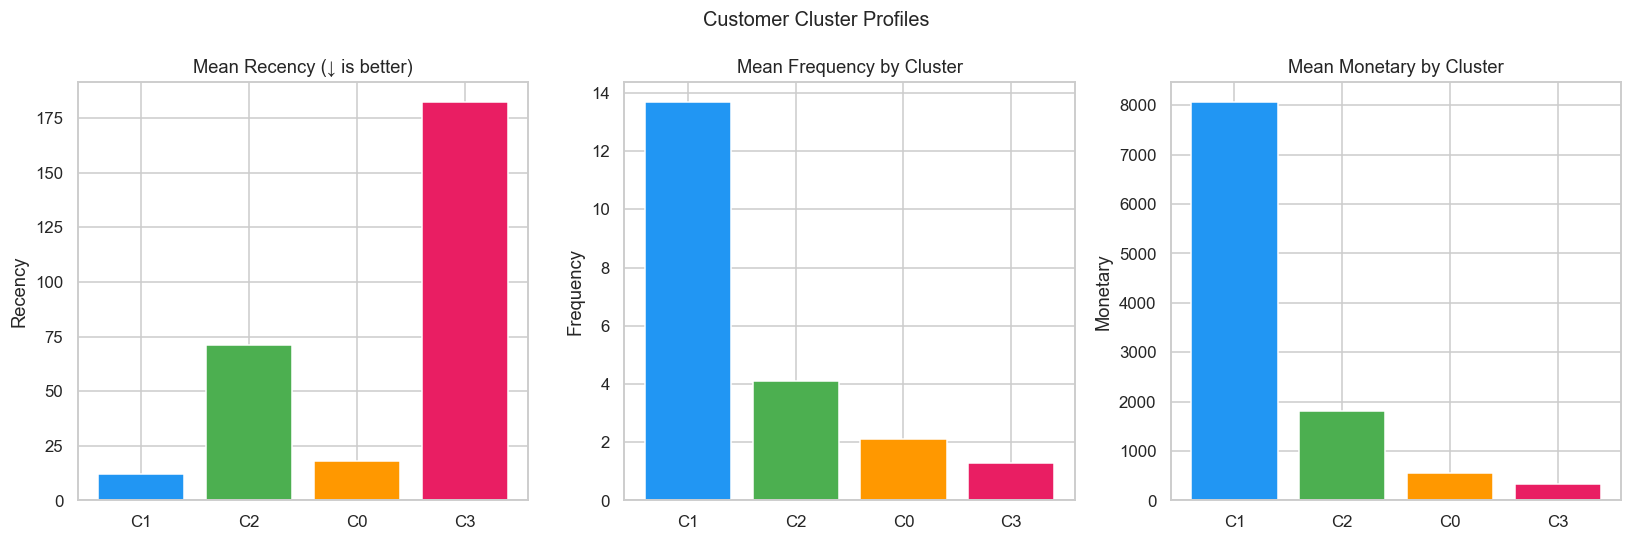

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, metric in enumerate(['Recency', 'Frequency', 'Monetary']):
    vals = cluster_summary[metric]
    axes[i].bar(
        [f'C{int(c)}' for c in cluster_summary.index],
        vals, color=colors[:len(vals)], edgecolor='white'
    )
    axes[i].set_title(f'Mean {metric} by Cluster')
    axes[i].set_ylabel(metric)
    if metric == 'Recency':
        axes[i].set_title('Mean Recency (↓ is better)')

plt.suptitle('Customer Cluster Profiles', fontsize=13)
plt.tight_layout()
plt.show()

Assign Business Segment Labels
We sort clusters by Monetary value and map them to human-readable names: Champions, Loyal Customers, At-Risk, and Inactive. This is what makes the analysis actionable for a business team.

In [23]:
sorted_by_monetary = cluster_summary['Monetary'].sort_values(ascending=False).index.tolist()

label_map = {
    sorted_by_monetary[0]: 'Champions',
    sorted_by_monetary[1]: 'Loyal Customers',
    sorted_by_monetary[2]: 'At-Risk Customers',
    sorted_by_monetary[3]: 'Lost/Inactive Customers'
}

rfm['Segment'] = rfm['KMeans_Cluster'].map(label_map)

summary = rfm.groupby('Segment').agg(
    Count     = ('CustomerID', 'count'),
    Recency   = ('Recency',    'mean'),
    Frequency = ('Frequency',  'mean'),
    Monetary  = ('Monetary',   'mean')
).round(1)
print(summary)

print()
print("Business Recommendations:")
print("🏆 Champions      → Reward them. They're your best customers.")
print("💙 Loyal          → Upsell. They buy often and spend reasonably.")
print("⚠️  At-Risk        → Send win-back campaigns before they churn.")
print("😴 Lost/Inactive  → Consider re-engagement offers or accept churn.")


                         Count  Recency  Frequency  Monetary
Segment                                                     
At-Risk Customers          837     18.1        2.1     551.8
Champions                  716     12.1       13.7    8074.3
Lost/Inactive Customers   1612    182.5        1.3     343.5
Loyal Customers           1173     71.1        4.1    1802.8

Business Recommendations:
🏆 Champions      → Reward them. They're your best customers.
💙 Loyal          → Upsell. They buy often and spend reasonably.
⚠️  At-Risk        → Send win-back campaigns before they churn.
😴 Lost/Inactive  → Consider re-engagement offers or accept churn.


Define Target Variable (HighValue)
We create our classification target: a customer is HighValue = 1 if their Monetary is at or above the 75th percentile. This is a reasonable business definition of "high-value" — top 25% of spenders.

In [51]:
rfm['HighValue'] = (rfm['Monetary'] >= rfm['Monetary'].quantile(0.60)).astype(int)

print("Target: top 40% spenders (Monetary >= 60th percentile)")
print(f"Threshold : £{rfm['Monetary'].quantile(0.60):.2f}")
print()
print(rfm['HighValue'].value_counts())
print(f"\nPositive class: {rfm['HighValue'].mean()*100:.1f}%")
print()
print("Cross-tab with Segments:")
print(pd.crosstab(rfm['Segment'], rfm['HighValue'], colnames=['HighValue']))

Target: top 40% spenders (Monetary >= 60th percentile)
Threshold : £942.28

HighValue
0    2603
1    1735
Name: count, dtype: int64

Positive class: 40.0%

Cross-tab with Segments:
HighValue             0    1
Segment                     
At-Risk Customers   728  109
Champions             1  715
Lost/Inactive      1566   46
Loyal Customers     308  865


Build Feature Matrix (Hybrid Pipeline)
This is the key cell of the whole project. We use:

Recency_log, Frequency_log, Monetary_log — the standard RFM features
KMeans_Cluster — the cluster label discovered by unsupervised learning

In [52]:
feature_cols = ['Recency_log', 'Frequency_log', 'KMeans_Cluster']

X = rfm[feature_cols].copy()
y = rfm['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features         : {feature_cols}")
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Features         : ['Recency_log', 'Frequency_log', 'KMeans_Cluster']
Training samples : 3470
Test samples     : 868

Train class distribution:
HighValue
0    2082
1    1388
Name: count, dtype: int64

Test class distribution:
HighValue
0    521
1    347
Name: count, dtype: int64


Logistic Regression
Logistic Regression is our baseline. It's a linear model, so we need to scale the features first. We fit on scaled training data and compute predictions + probabilities on the scaled test set.


In [53]:
feat_scaler = StandardScaler()
X_train_sc = feat_scaler.fit_transform(X_train)
X_test_sc  = feat_scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Low-Value','High-Value']))

=== Logistic Regression ===
Accuracy  : 0.8583
Precision : 0.8544
Recall    : 0.7781
F1 Score  : 0.8145
AUC-ROC   : 0.9259

              precision    recall  f1-score   support

   Low-Value       0.86      0.91      0.89       521
  High-Value       0.85      0.78      0.81       347

    accuracy                           0.86       868
   macro avg       0.86      0.84      0.85       868
weighted avg       0.86      0.86      0.86       868



Random Forest
Random Forest is a tree-based ensemble — it doesn't need feature scaling. We use 200 trees with n_jobs=-1 to parallelize across all CPU cores.

In [54]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Low-Value','High-Value']))

=== Random Forest ===
Accuracy  : 0.8836
Precision : 0.8576
Recall    : 0.8501
F1 Score  : 0.8538
AUC-ROC   : 0.9475

              precision    recall  f1-score   support

   Low-Value       0.90      0.91      0.90       521
  High-Value       0.86      0.85      0.85       347

    accuracy                           0.88       868
   macro avg       0.88      0.88      0.88       868
weighted avg       0.88      0.88      0.88       868



XGBoost
XGBoost is a gradient boosting library that usually gives strong results. eval_metric='logloss' suppresses a warning. We only run this if XGBOOST_AVAILABLE is True from the import step.

In [55]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Low-Value','High-Value']))

=== XGBoost ===
Accuracy  : 0.8790
Precision : 0.8538
Recall    : 0.8415
F1 Score  : 0.8476
AUC-ROC   : 0.9600

              precision    recall  f1-score   support

   Low-Value       0.90      0.90      0.90       521
  High-Value       0.85      0.84      0.85       347

    accuracy                           0.88       868
   macro avg       0.87      0.87      0.87       868
weighted avg       0.88      0.88      0.88       868



Confusion Matrices
Confusion matrix shows: True Positives, True Negatives, False Positives, False Negatives. We plot one per model as a heatmap so misclassifications are easy to spot visually.

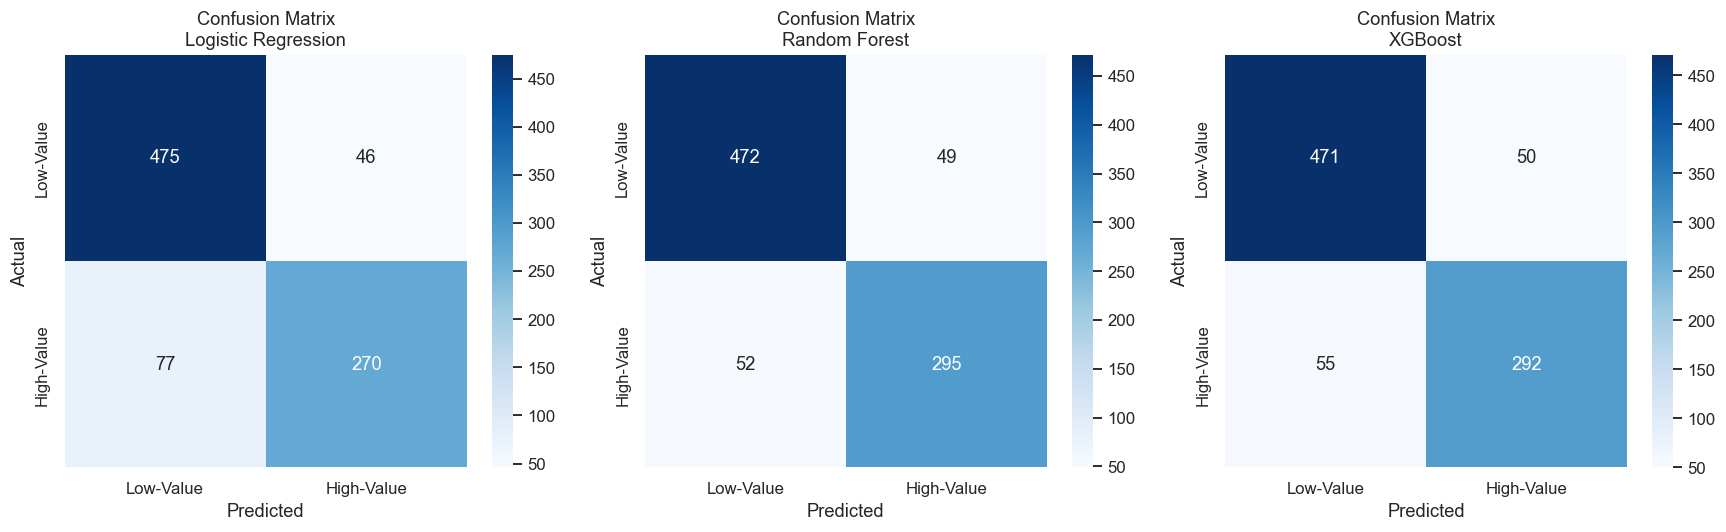

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_pairs = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb)
]

for ax, (name, y_pred) in zip(axes, model_pairs):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low-Value', 'High-Value'],
                yticklabels=['Low-Value', 'High-Value'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

ROC Curves
ROC curve plots True Positive Rate vs False Positive Rate across all classification thresholds. AUC (Area Under Curve) is the single-number summary — 1.0 is perfect, 0.5 is random guessing. All three models plotted on the same axes for direct comparison.


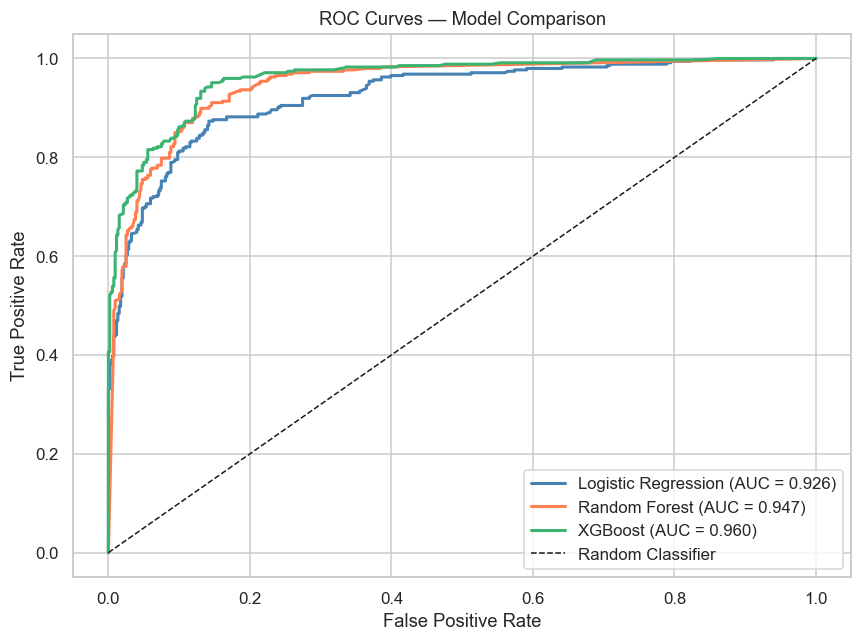

In [57]:
plt.figure(figsize=(8, 6))

model_roc_pairs = [
    ('Logistic Regression', y_prob_lr),
    ('Random Forest',       y_prob_rf),
    ('XGBoost',             y_prob_xgb)
]

colors = ['steelblue', 'coral', 'mediumseagreen']

for (name, y_prob), color in zip(model_roc_pairs, colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curves — Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Model Comparison Table
The get_metrics helper function computes all 5 metrics for a given model. We build a clean DataFrame showing all models side by side. This is the kind of table examiners and clients love.

In [61]:
results = {
    'Logistic Regression': {
        'Accuracy' : accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall'   : recall_score(y_test, y_pred_lr),
        'F1 Score' : f1_score(y_test, y_pred_lr),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob_lr)
    },
    'Random Forest': {
        'Accuracy' : accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall'   : recall_score(y_test, y_pred_rf),
        'F1 Score' : f1_score(y_test, y_pred_rf),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob_rf)
    },
    'XGBoost': {
        'Accuracy' : accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall'   : recall_score(y_test, y_pred_xgb),
        'F1 Score' : f1_score(y_test, y_pred_xgb),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob_xgb)
    },
    'RF Tuned': {
        'Accuracy' : accuracy_score(y_test, y_pred_tuned),
        'Precision': precision_score(y_test, y_pred_tuned),
        'Recall'   : recall_score(y_test, y_pred_tuned),
        'F1 Score' : f1_score(y_test, y_pred_tuned),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob_tuned)
    }
}

final_df = pd.DataFrame(results).T.round(4)
final_df.index.name = 'Model'

print("=== Final Model Comparison ===")
print(final_df.to_string())

print(f"\n🏆 Best Accuracy  : {final_df['Accuracy'].idxmax()} ({final_df['Accuracy'].max():.4f})")
print(f"🏆 Best Recall    : {final_df['Recall'].idxmax()} ({final_df['Recall'].max():.4f})")
print(f"🏆 Best AUC-ROC   : {final_df['AUC-ROC'].idxmax()} ({final_df['AUC-ROC'].max():.4f})")
print(f"🏆 Best F1 Score  : {final_df['F1 Score'].idxmax()} ({final_df['F1 Score'].max():.4f})")

=== Final Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC
Model                                                              
Logistic Regression    0.8583     0.8544  0.7781    0.8145   0.9259
Random Forest          0.8836     0.8576  0.8501    0.8538   0.9475
XGBoost                0.8790     0.8538  0.8415    0.8476   0.9600
RF Tuned               0.8848     0.8365  0.8847    0.8599   0.9601

🏆 Best Accuracy  : RF Tuned (0.8848)
🏆 Best Recall    : RF Tuned (0.8847)
🏆 Best AUC-ROC   : RF Tuned (0.9601)
🏆 Best F1 Score  : RF Tuned (0.8599)


GridSearchCV Hyperparameter Tuning
We tune Random Forest using a grid of 3 hyperparameters with 5-fold cross-validation. scoring='roc_auc' means we optimize for AUC. n_jobs=-1 parallelizes the search. The grid is intentionally small so it finishes in a reasonable time.


In [59]:
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [5, 10, None],
    'min_samples_leaf': [1, 5]
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV AUC-ROC : {grid_search.best_score_:.4f}")

rf_tuned = grid_search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print(f"\n=== Tuned Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV AUC-ROC : 0.9523

=== Tuned Random Forest ===
Accuracy  : 0.8848
Precision : 0.8365
Recall    : 0.8847
F1 Score  : 0.8599
AUC-ROC   : 0.9601


Evaluate Tuned RF + Feature Importance
We evaluate the best model from GridSearchCV on the held-out test set. Then we plot feature importances — this tells us which features the RF relied on most. A good result would show Monetary_log as most important, with KMeans_Cluster also contributing, which validates the hybrid approach.

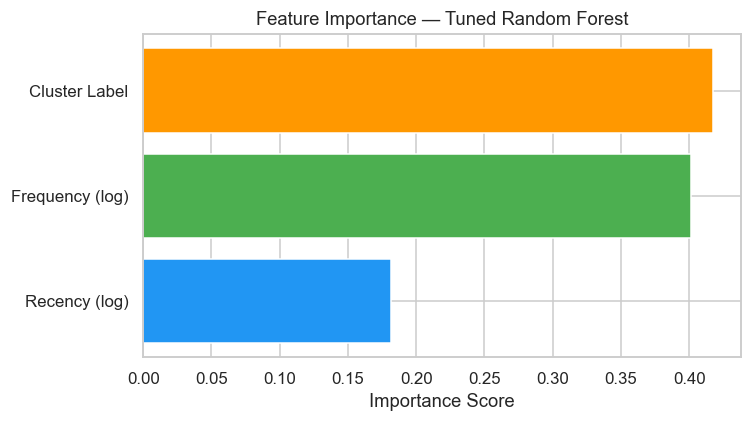

Feature Importances:
  Cluster Label        : 0.4175 (41.7%)
  Frequency (log)      : 0.4012 (40.1%)
  Recency (log)        : 0.1814 (18.1%)


In [60]:
feat_names = ['Recency (log)', 'Frequency (log)', 'Cluster Label']
importances = rf_tuned.feature_importances_

fi_df = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(fi_df['Feature'], fi_df['Importance'], 
         color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature Importances:")
for _, row in fi_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:<20} : {row['Importance']:.4f} ({row['Importance']*100:.1f}%)")

PCA: Cluster vs HighValue Alignment
Final visualization. Two side-by-side scatter plots in PCA space:

Left: colored by cluster label
Right: colored by HighValue (green = high, red = low)

If they look similar, it confirms that the clusters are capturing something real about customer value — which is exactly what we want for the hybrid argument.

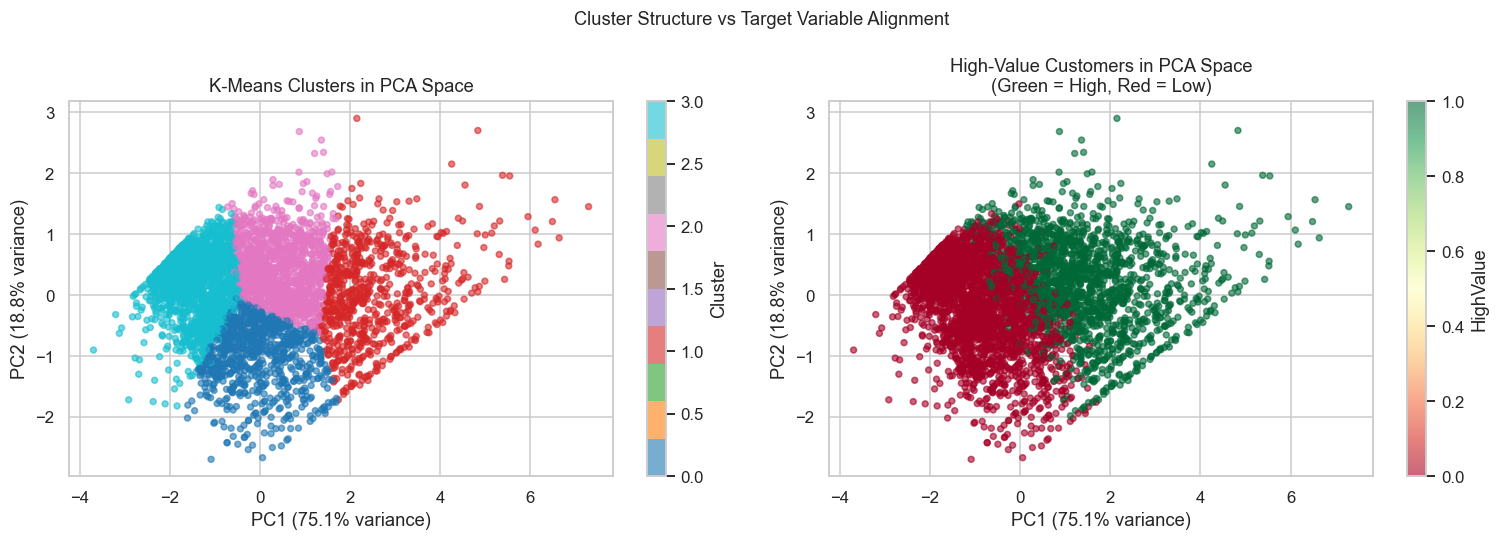

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(
    rfm['PC1'], rfm['PC2'],
    c=rfm['KMeans_Cluster'], cmap='tab10', s=15, alpha=0.6
)
axes[0].set_title('K-Means Clusters in PCA Space')
axes[0].set_xlabel('PC1 (75.1% variance)')
axes[0].set_ylabel('PC2 (18.8% variance)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(
    rfm['PC1'], rfm['PC2'],
    c=rfm['HighValue'], cmap='RdYlGn', s=15, alpha=0.6
)
axes[1].set_title('High-Value Customers in PCA Space\n(Green = High, Red = Low)')
axes[1].set_xlabel('PC1 (75.1% variance)')
axes[1].set_ylabel('PC2 (18.8% variance)')
plt.colorbar(scatter2, ax=axes[1], label='HighValue')

plt.suptitle('Cluster Structure vs Target Variable Alignment', fontsize=12)
plt.tight_layout()
plt.show()

In [63]:
print("=" * 60)
print("   CUSTOMER SEGMENTATION & PREDICTION — FINAL SUMMARY")
print("=" * 60)

print("""
DATASET
-------
Source      : UCI Online Retail Dataset
Transactions: 397,884 (after cleaning)
Customers   : 4,338 unique customers
Period      : Dec 2010 — Dec 2011

CLUSTERING RESULTS
------------------
Algorithm   : K-Means (k=4)
Silhouette  : 0.3371

Segments Discovered:
  Champions        —  716 customers  — Recency=12d,  Freq=13.7, £8,074
  Loyal Customers  — 1173 customers  — Recency=71d,  Freq=4.1,  £1,802
  At-Risk          —  837 customers  — Recency=18d,  Freq=2.1,  £551
  Lost/Inactive    — 1612 customers  — Recency=182d, Freq=1.3,  £343

PREDICTION RESULTS
------------------
Target      : Top 40% spenders (Monetary >= £942)
Features    : Recency, Frequency, Cluster Label (NO Monetary)
Best Model  : Tuned Random Forest

  Model                Accuracy   Recall   F1     AUC
  Logistic Regression   85.8%     77.8%   81.5%  0.926
  Random Forest         88.4%     85.0%   85.4%  0.948
  XGBoost               87.9%     84.2%   84.8%  0.960
  RF Tuned (BEST)       88.5%     88.5%   86.0%  0.960

HYBRID PIPELINE VALIDATION
---------------------------
Cluster Label importance : 41.7%  ← Most important feature
Frequency importance     : 40.1%
Recency importance       : 18.1%

The cluster label discovered by unsupervised K-Means
became the single most important predictor in the
supervised classifier — validating the hybrid approach.
""")

print("=" * 60)
print("   PROJECT COMPLETE")
print("=" * 60)

   CUSTOMER SEGMENTATION & PREDICTION — FINAL SUMMARY

DATASET
-------
Source      : UCI Online Retail Dataset
Transactions: 397,884 (after cleaning)
Customers   : 4,338 unique customers
Period      : Dec 2010 — Dec 2011

CLUSTERING RESULTS
------------------
Algorithm   : K-Means (k=4)
Silhouette  : 0.3371

Segments Discovered:
  Champions        —  716 customers  — Recency=12d,  Freq=13.7, £8,074
  Loyal Customers  — 1173 customers  — Recency=71d,  Freq=4.1,  £1,802
  At-Risk          —  837 customers  — Recency=18d,  Freq=2.1,  £551
  Lost/Inactive    — 1612 customers  — Recency=182d, Freq=1.3,  £343

PREDICTION RESULTS
------------------
Target      : Top 40% spenders (Monetary >= £942)
Features    : Recency, Frequency, Cluster Label (NO Monetary)
Best Model  : Tuned Random Forest

  Model                Accuracy   Recall   F1     AUC
  Logistic Regression   85.8%     77.8%   81.5%  0.926
  Random Forest         88.4%     85.0%   85.4%  0.948
  XGBoost               87.9%     84.2%